In [3]:
# Extract register tokens from all validation cases
import numpy as np
from pathlib import Path

results_dir = Path("/nfs/data/nii/data1/Analysis/camaret___in_context_segmentation/ANALYSIS_20251122/results/totalseg2d_patch_icl")
case_dirs = sorted([d for d in results_dir.iterdir() if d.is_dir()])
print(f"Found {len(case_dirs)} cases")

Found 365 cases


In [4]:
# Load register tokens for all cases
# Shape per case: (8 registers, 512 dims)

register_tokens = {}  # case_name -> (8, 512)
case_names = []
labels = []  # Extract label from case name (e.g., "aorta" from "case0000_aorta_y")

for case_dir in case_dirs:
    reg_file = case_dir / "level0_register_tokens.npy"
    if reg_file.exists():
        tokens = np.load(reg_file)  # (8, 512)
        case_name = case_dir.name
        register_tokens[case_name] = tokens
        case_names.append(case_name)
        
        # Parse label from case name: case0000_labelname_x/y/z
        parts = case_name.split('_')
        label = '_'.join(parts[1:-1])  # Everything between case ID and axis
        labels.append(label)

print(f"Loaded {len(register_tokens)} cases")
print(f"Register shape: {next(iter(register_tokens.values())).shape}")
print(f"Unique labels: {len(set(labels))}")

Loaded 365 cases
Register shape: (8, 512)
Unique labels: 16


In [5]:
# Stack into arrays for analysis
all_tokens = np.stack([register_tokens[name] for name in case_names], axis=0)  # (N, 8, 512)
labels_array = np.array(labels)
unique_labels = sorted(set(labels))

print(f"All tokens shape: {all_tokens.shape}")
print(f"Labels: {unique_labels[:10]}...")  # Show first 10

All tokens shape: (365, 8, 512)
Labels: ['aorta', 'autochthon_left', 'autochthon_right', 'esophagus', 'heart', 'iliopsoas_left', 'liver', 'lung_lower_lobe_left', 'lung_lower_lobe_right', 'lung_upper_lobe_left']...


In [6]:
# Basic statistics per register token
print("=== Register Token Statistics ===\n")

for reg_idx in range(8):
    reg_tokens = all_tokens[:, reg_idx, :]  # (N, 512)
    mean_norm = np.linalg.norm(reg_tokens, axis=1).mean()
    std_norm = np.linalg.norm(reg_tokens, axis=1).std()
    
    # Variance across cases (how much does this register vary?)
    variance = reg_tokens.var(axis=0).mean()
    
    print(f"Register {reg_idx}: norm={mean_norm:.2f}±{std_norm:.2f}, var={variance:.4f}")

=== Register Token Statistics ===

Register 0: norm=21.91±0.04, var=0.1182
Register 1: norm=21.92±0.04, var=0.1233
Register 2: norm=21.92±0.04, var=0.1189
Register 3: norm=21.91±0.04, var=0.1140
Register 4: norm=21.92±0.04, var=0.1165
Register 5: norm=21.92±0.04, var=0.1229
Register 6: norm=21.92±0.04, var=0.1223
Register 7: norm=21.91±0.04, var=0.1184


In [7]:
# Average register tokens per anatomical label
label_avg_tokens = {}  # label -> (8, 512)

for label in unique_labels:
    mask = labels_array == label
    label_tokens = all_tokens[mask]  # (n_cases, 8, 512)
    label_avg_tokens[label] = label_tokens.mean(axis=0)  # (8, 512)

print(f"Computed average tokens for {len(label_avg_tokens)} labels")
print(f"Sample labels: {list(label_avg_tokens.keys())[:5]}")

Computed average tokens for 16 labels
Sample labels: ['aorta', 'autochthon_left', 'autochthon_right', 'esophagus', 'heart']


In [8]:
# Compute cosine similarity between label-averaged register tokens
from sklearn.metrics.pairwise import cosine_similarity

# Flatten registers for each label: (8, 512) -> (4096,)
label_vectors = np.stack([label_avg_tokens[l].flatten() for l in unique_labels])  # (n_labels, 4096)

# Cosine similarity matrix
sim_matrix = cosine_similarity(label_vectors)

print(f"Similarity matrix shape: {sim_matrix.shape}")
print(f"Similarity range: [{sim_matrix.min():.3f}, {sim_matrix.max():.3f}]")
print(f"Mean off-diagonal similarity: {(sim_matrix.sum() - np.trace(sim_matrix)) / (sim_matrix.size - len(unique_labels)):.3f}")

Similarity matrix shape: (16, 16)
Similarity range: [0.854, 1.000]
Mean off-diagonal similarity: 0.963


In [9]:
# Save extracted data
output_dir = Path(".")
np.savez(output_dir / "register_tokens_data.npz",
         all_tokens=all_tokens,
         case_names=case_names,
         labels=labels,
         unique_labels=unique_labels)

print(f"Saved to {output_dir / 'register_tokens_data.npz'}")

Saved to register_tokens_data.npz


In [10]:
# 2D projection per register token using UMAP
from umap import UMAP
import matplotlib.pyplot as plt

# Compute UMAP embedding for each register separately
embeddings = {}  # reg_idx -> (N, 2)

for reg_idx in range(8):
    reg_tokens = all_tokens[:, reg_idx, :]  # (N, 512)
    reducer = UMAP(n_components=2, n_neighbors=15, min_dist=0.1)
    embeddings[reg_idx] = reducer.fit_transform(reg_tokens)
    print(f"Register {reg_idx}: embedded {reg_tokens.shape} -> {embeddings[reg_idx].shape}")

Register 0: embedded (365, 512) -> (365, 2)
Register 1: embedded (365, 512) -> (365, 2)
Register 2: embedded (365, 512) -> (365, 2)
Register 3: embedded (365, 512) -> (365, 2)
Register 4: embedded (365, 512) -> (365, 2)
Register 5: embedded (365, 512) -> (365, 2)
Register 6: embedded (365, 512) -> (365, 2)
Register 7: embedded (365, 512) -> (365, 2)


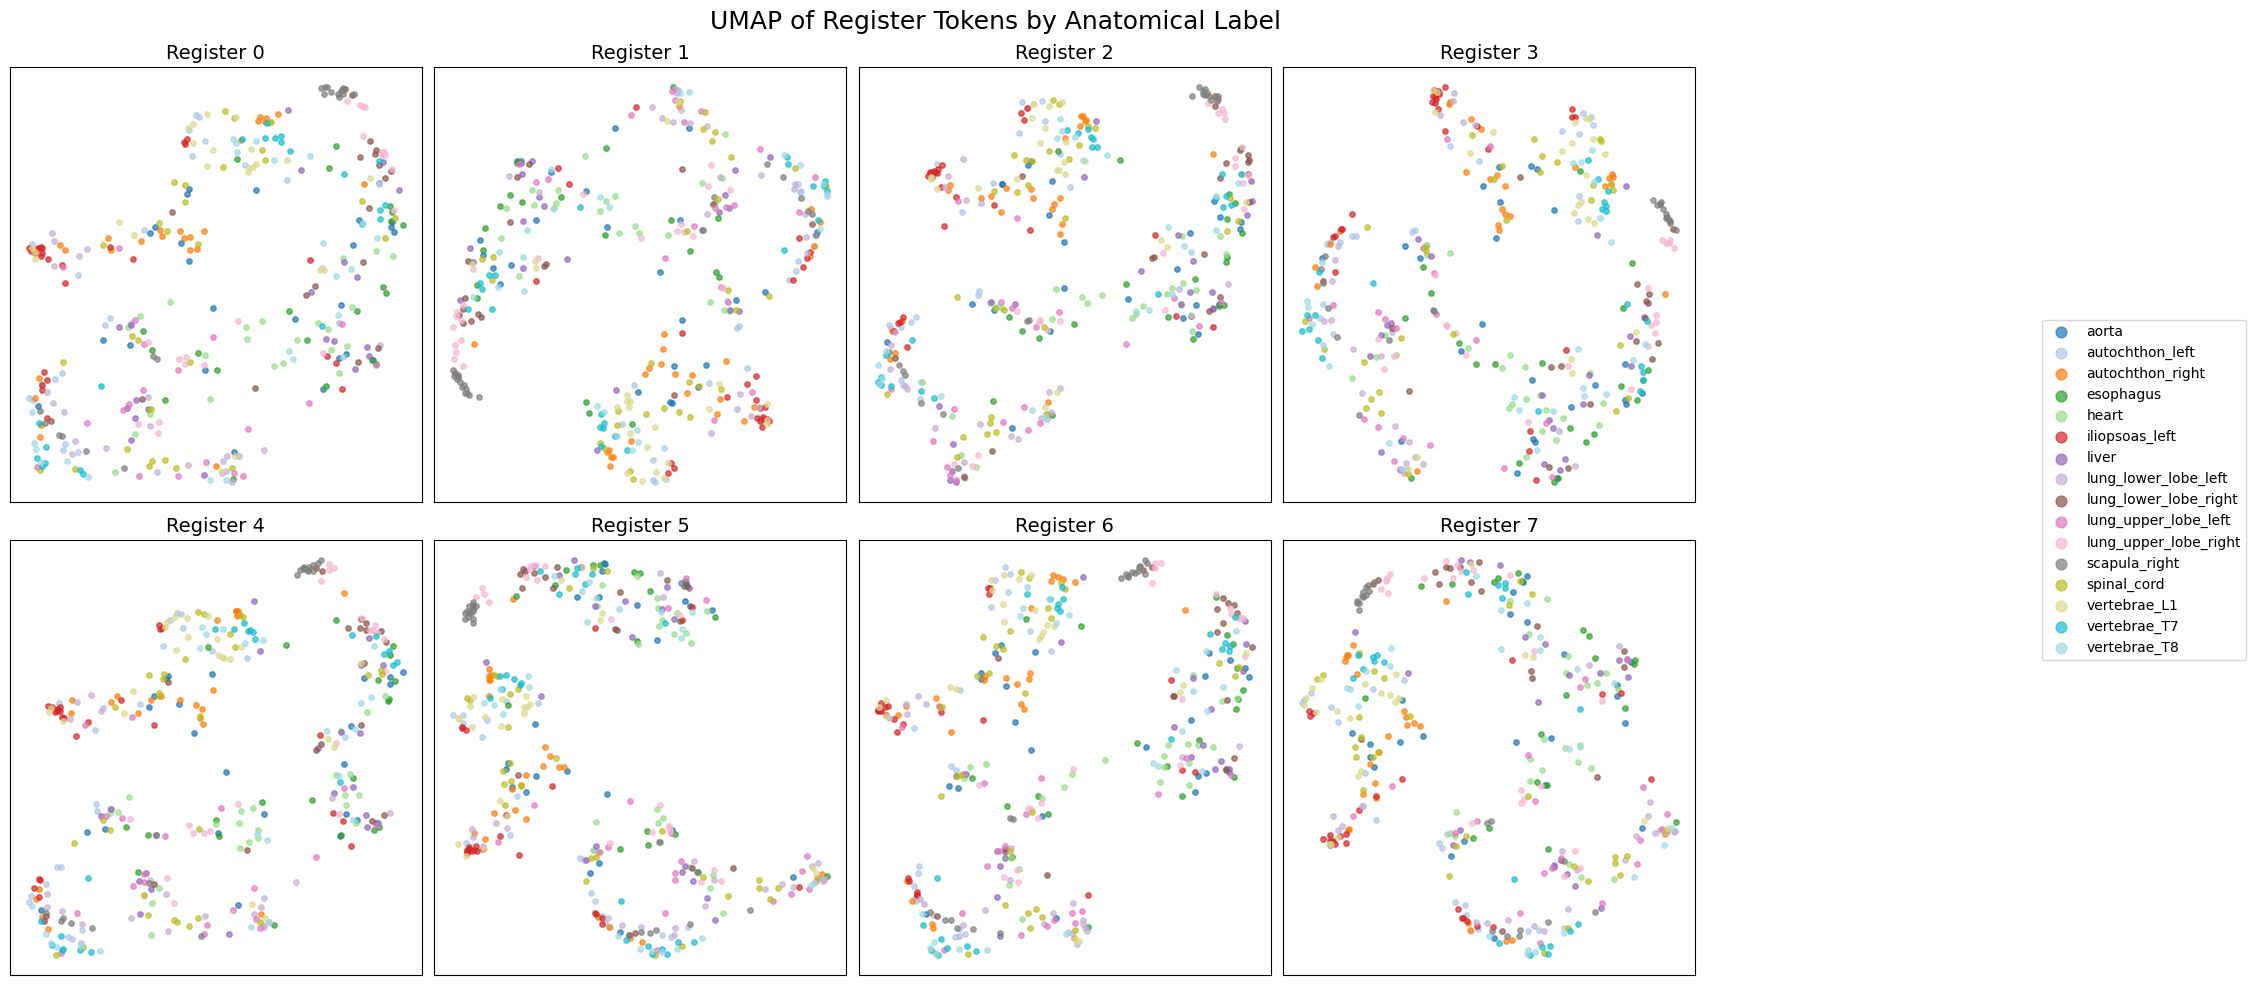

In [ ]:
# Plot embeddings per register token
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Create color map for labels
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))
label_to_color = {label: colors[i] for i, label in enumerate(unique_labels)}

# Store handles for legend (only need one set)
legend_handles = []
legend_labels = []

for reg_idx, ax in enumerate(axes.flat):
    emb = embeddings[reg_idx]
    
    for label in unique_labels:
        mask = labels_array == label
        scatter = ax.scatter(emb[mask, 0], emb[mask, 1], 
                           c=[label_to_color[label]], s=15, alpha=0.7, label=label)
        
        # Only collect legend info from first subplot
        if reg_idx == 0:
            legend_handles.append(scatter)
            legend_labels.append(label)
    
    ax.set_title(f'Register {reg_idx}', fontsize=14)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('UMAP of Register Tokens by Anatomical Label', y=0.98, fontsize=18)

# Add legend to the right of the plot
fig.legend(legend_handles, legend_labels, loc='center left', bbox_to_anchor=(1.05, 0.5), 
           fontsize=9, markerscale=1.5, frameon=True, ncol=1)

plt.tight_layout()
plt.subplots_adjust(right=0.80)  # Make room for legend
plt.show()

In [12]:
# Load target mask sizes from saved results
import nibabel as nib

mask_sizes = []
for case_name in case_names:
    case_dir = results_dir / case_name
    gt_mask = nib.load(case_dir / 'gt_mask.nii.gz').get_fdata()
    mask_size = (gt_mask > 0).sum()
    mask_sizes.append(mask_size)

mask_sizes = np.array(mask_sizes)
print(f"Mask sizes: min={mask_sizes.min():.0f}, max={mask_sizes.max():.0f}, mean={mask_sizes.mean():.0f}")

Mask sizes: min=1, max=29759, mean=3183


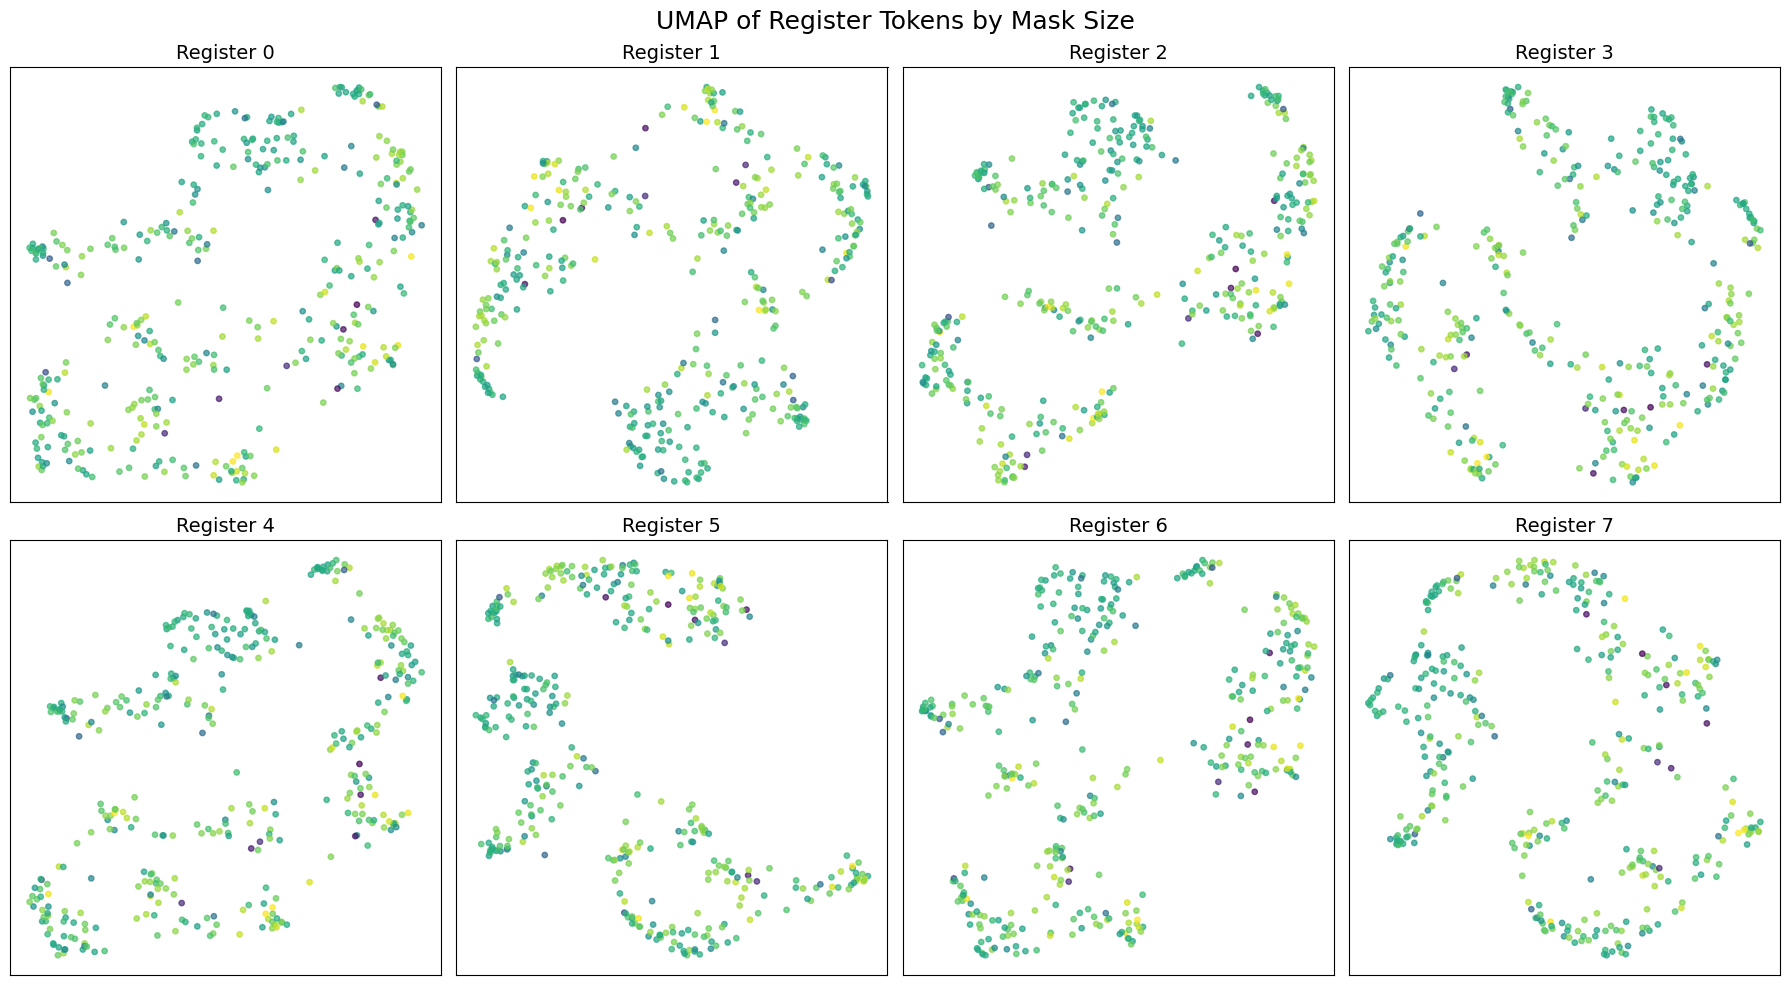

In [19]:
# Plot embeddings colored by mask size (log scale)
fig, axes = plt.subplots(2, 4, figsize=(18, 10))

log_sizes = np.log10(mask_sizes + 1)  # Log scale for better visualization

for reg_idx, ax in enumerate(axes.flat):
    emb = embeddings[reg_idx]
    sc = ax.scatter(emb[:, 0], emb[:, 1], c=log_sizes, cmap='viridis', s=15, alpha=0.7)
    ax.set_title(f'Register {reg_idx}', fontsize=14)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('UMAP of Register Tokens by Mask Size', y=0.98, fontsize=18)
#cbar = plt.colorbar(sc, ax=axes, shrink=0.8, label='log10(mask size)')
#cbar.ax.tick_params(labelsize=12)
#cbar.set_label('log10(mask size)', fontsize=14)
plt.tight_layout()
plt.show()

In [14]:
# Compute distance between target and context mask centroids
from scipy.ndimage import center_of_mass

target_context_distances = []
for case_name in case_names:
    case_dir = results_dir / case_name
    
    # Load masks
    target_mask = nib.load(case_dir / 'gt_mask.nii.gz').get_fdata()
    context_mask = nib.load(case_dir / 'context0_gt_mask.nii.gz').get_fdata()
    
    # Compute centroids
    target_centroid = np.array(center_of_mass(target_mask))
    context_centroid = np.array(center_of_mass(context_mask))
    
    # Euclidean distance
    dist = np.linalg.norm(target_centroid - context_centroid)
    target_context_distances.append(dist)

target_context_distances = np.array(target_context_distances)
print(f"Target-context distance: min={target_context_distances.min():.1f}, max={target_context_distances.max():.1f}, mean={target_context_distances.mean():.1f}")

Target-context distance: min=2.4, max=236.7, mean=60.8


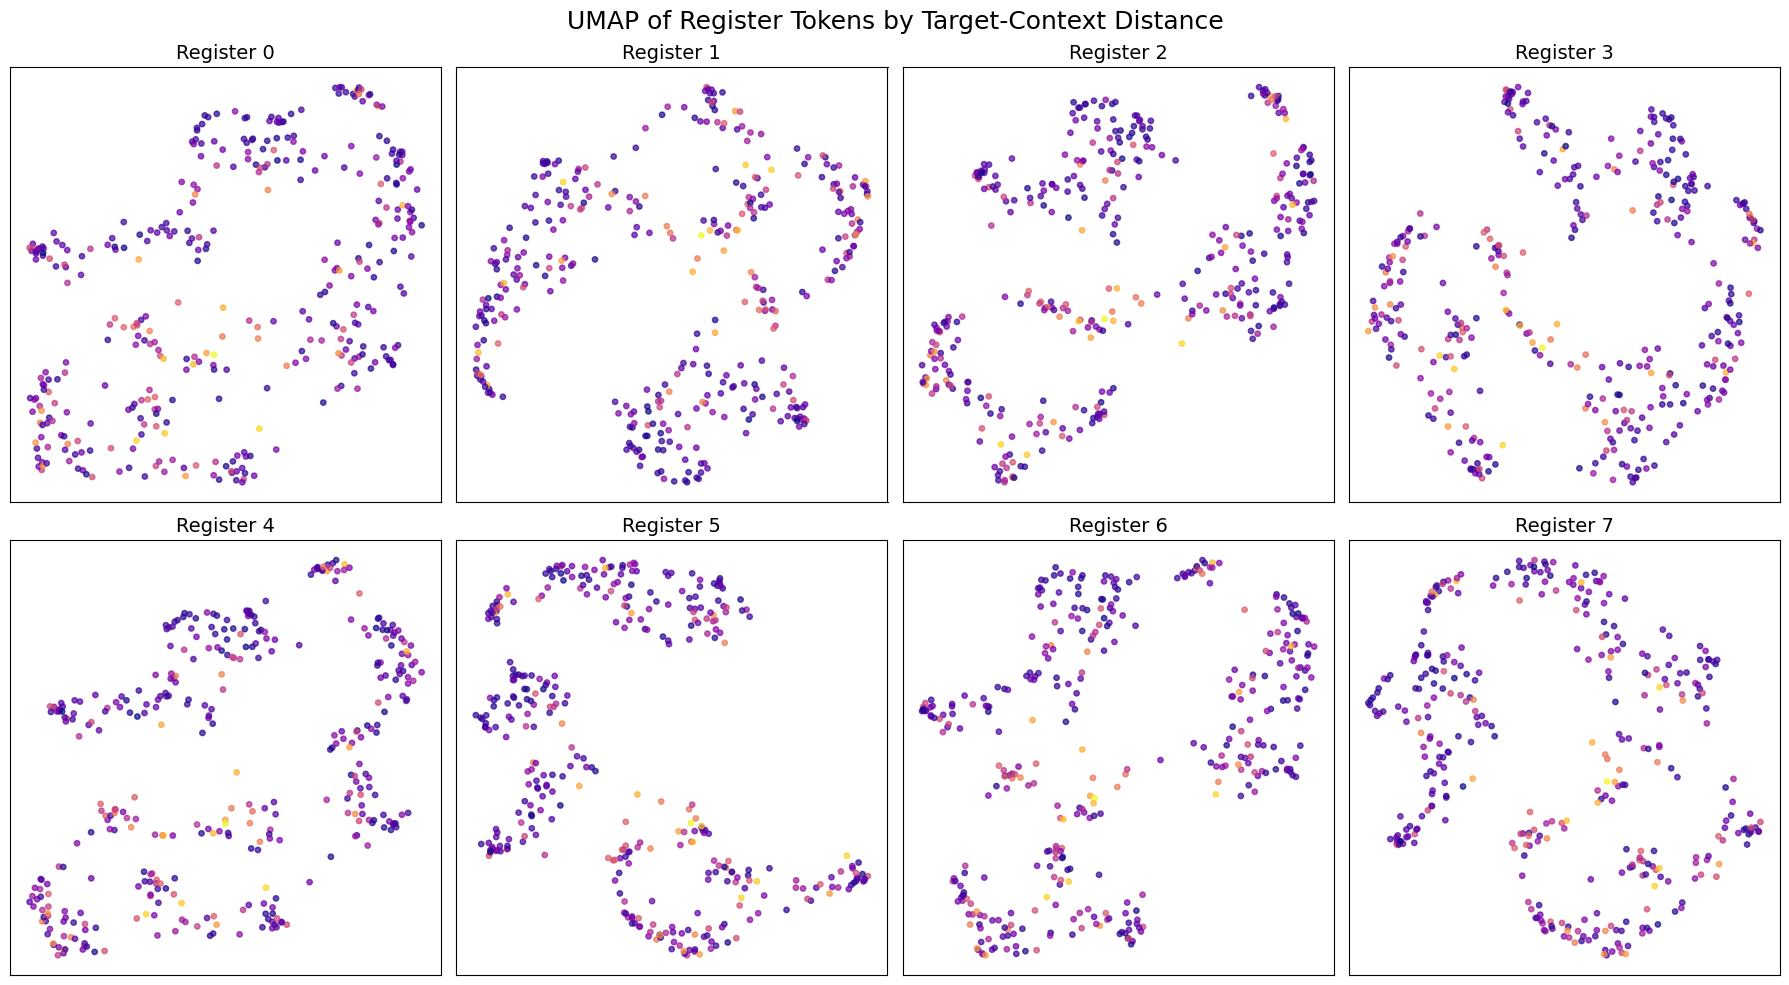

In [20]:
# Plot embeddings colored by target-context distance
fig, axes = plt.subplots(2, 4, figsize=(18, 10))

for reg_idx, ax in enumerate(axes.flat):
    emb = embeddings[reg_idx]
    sc = ax.scatter(emb[:, 0], emb[:, 1], c=target_context_distances, cmap='plasma', s=15, alpha=0.7)
    ax.set_title(f'Register {reg_idx}', fontsize=14)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('UMAP of Register Tokens by Target-Context Distance', y=0.98, fontsize=18)
#cbar = plt.colorbar(sc, ax=axes, shrink=0.8, label='Centroid distance (pixels)')
#cbar.ax.tick_params(labelsize=12)
#cbar.set_label('Centroid distance (pixels)', fontsize=14)
plt.tight_layout()
plt.show()